In [1]:
import xarray as xr

zarr_path = "s3://noaa-oar-sfsdev-pds/experiments/beta1/forecast/202603/atm_monthly.zarr"

ds = xr.open_zarr(
    zarr_path,
    storage_options={"anon": True}
)

print(ds)

<xarray.Dataset> Size: 18GB
Dimensions:       (member: 31, lead: 12, lat: 361, lon: 720)
Coordinates:
  * member        (member) int64 248B 0 1 2 3 4 5 6 7 ... 24 25 26 27 28 29 30
  * lead          (lead) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * lat           (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 89.0 89.5 90.0
  * lon           (lon) float64 6kB 0.0 0.5 1.0 1.5 ... 358.0 358.5 359.0 359.5
Data variables: (12/46)
    acpcpsfc      (member, lead, lat, lon) float32 387MB ...
    apcpsfc       (member, lead, lat, lon) float32 387MB ...
    avg_ishfsfc   (member, lead, lat, lon) float32 387MB ...
    avg_slhtfsfc  (member, lead, lat, lon) float32 387MB ...
    avg_utauasfc  (member, lead, lat, lon) float32 387MB ...
    avg_vtauasfc  (member, lead, lat, lon) float32 387MB ...
    ...            ...
    vpot850       (member, lead, lat, lon) float32 387MB ...
    watrsfc       (member, lead, lat, lon) float32 387MB ...
    z200          (member, lead, lat, lon) float32 387MB ...
   

In [3]:
print(ds["land"].attrs)

{'short_name': 'LAND_surface', 'long_name': 'Land Cover (0=sea, 1=land)', 'level': 'surface', 'units': 'Proportion'}


In [6]:
# Select one member and one lead
land = ds["land"].isel(
    member=0,
    lead=0
)

print(land)

<xarray.DataArray 'land' (lat: 361, lon: 720)> Size: 1MB
[259920 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5 90.0
  * lon      (lon) float64 6kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
    lead     int64 8B 0
    member   int64 8B 0
Attributes:
    short_name:  LAND_surface
    long_name:   Land Cover (0=sea, 1=land)
    level:       surface
    units:       Proportion


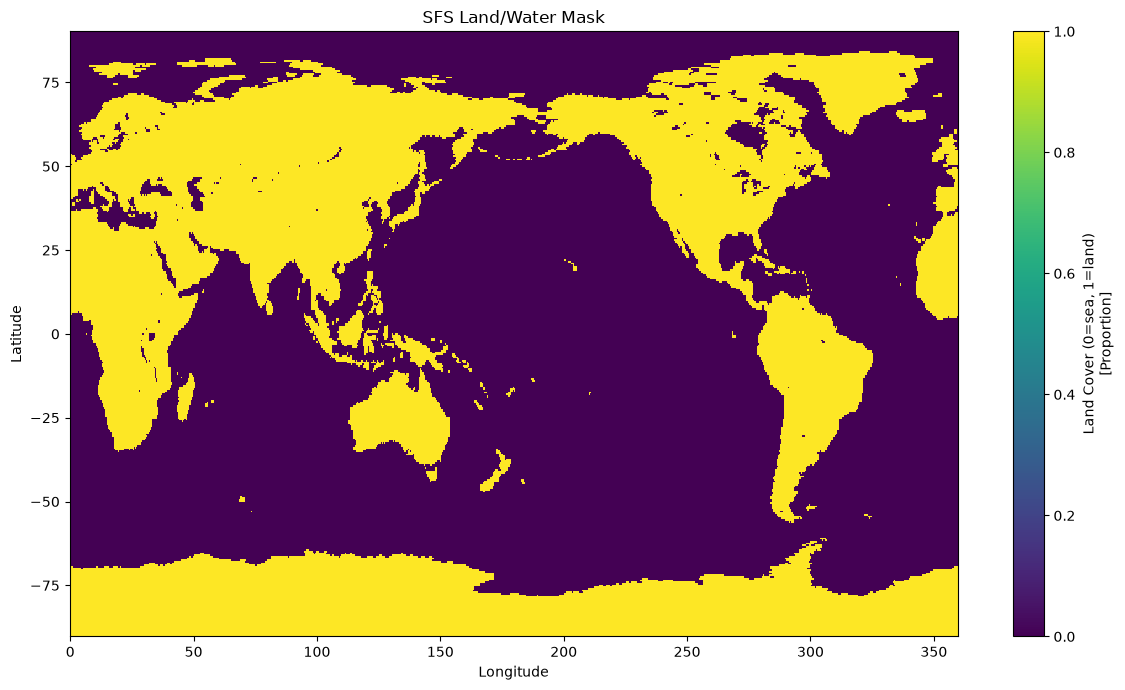

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 7))

land.plot(
    ax=ax,
    x="lon",
    y="lat"
)

ax.set_title("SFS Land/Water Mask")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

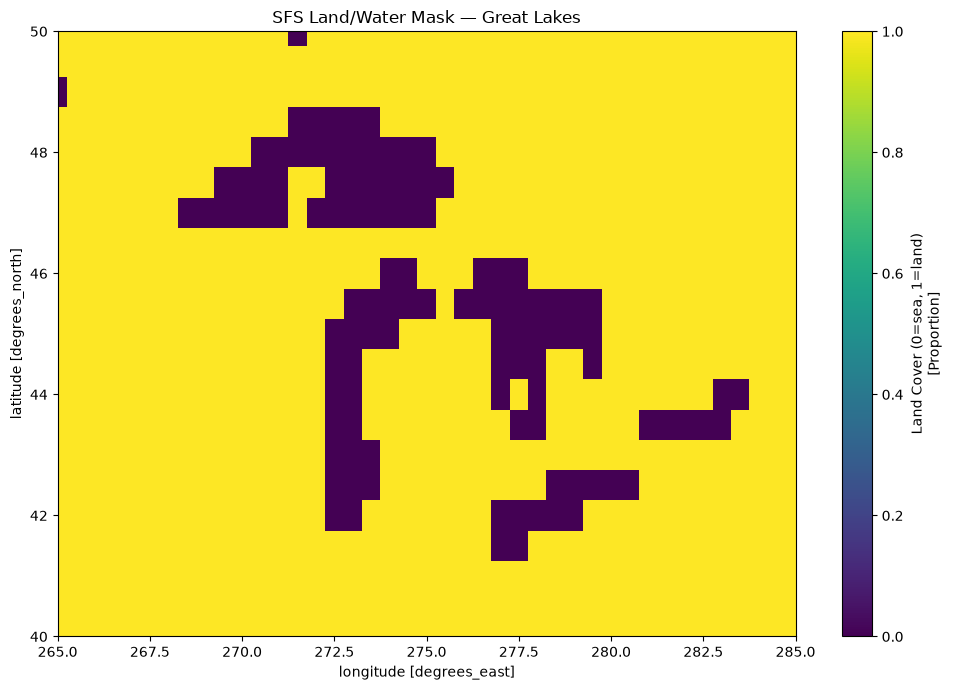

In [8]:
fig, ax = plt.subplots(figsize=(10, 7))

land.plot(ax=ax)

ax.set_xlim(265, 285)
ax.set_ylim(40, 50)

ax.set_title("SFS Land/Water Mask — Great Lakes")
plt.tight_layout()
plt.show()

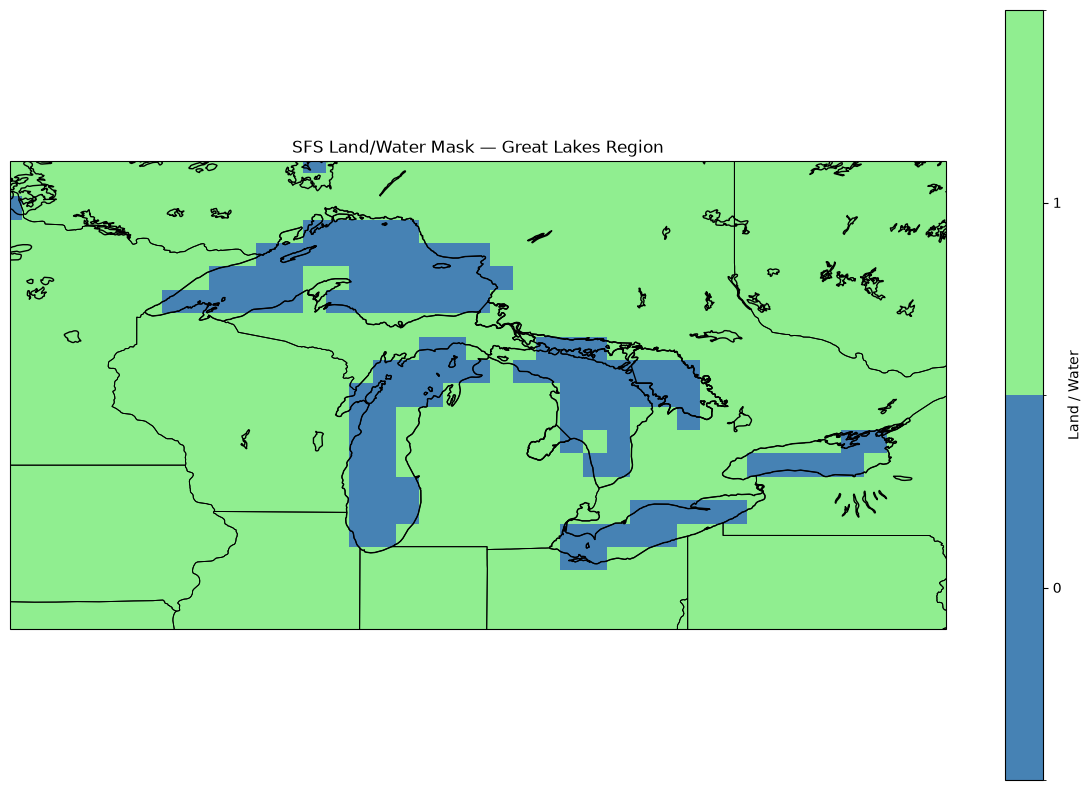

In [10]:
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---------------------------------------------------------
# Custom colormap: water = blue, land = green
# ---------------------------------------------------------

cmap = mcolors.ListedColormap([
    "steelblue",   # 0 = water
    "lightgreen"  # 1 = land
])

norm = mcolors.BoundaryNorm(
    boundaries=[-0.5, 0.5, 1.5],
    ncolors=2
)

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig = plt.figure(figsize=(12, 8))

ax = plt.axes(projection=ccrs.PlateCarree())

land.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    add_colorbar=True,
    cbar_kwargs={
        "ticks": [0, 1],
        "label": "Land / Water"
    }
)

# Great Lakes region
ax.set_extent([265, 285, 40, 50], crs=ccrs.PlateCarree())

# State boundaries
ax.add_feature(
    cfeature.STATES,
    edgecolor="black",
    linewidth=0.7
)

# Lake outlines
ax.add_feature(
    cfeature.LAKES,
    edgecolor="black",
    facecolor="none",
    linewidth=1.0
)

# Coastlines
ax.coastlines(
    resolution="10m",
    linewidth=0.8
)

ax.set_title("SFS Land/Water Mask — Great Lakes Region")

plt.tight_layout()
plt.show()